<a href="https://colab.research.google.com/github/RichardMorris/TRUR2290-25-26/blob/main/linear_regression_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Example

### Download Data set

In [ ]:
!curl -L -o ./salary-dataset-simple-linear-regression.zip https://www.kaggle.com/api/v1/datasets/download/abhishek14398/salary-dataset-simple-linear-regression
!unzip ./salary-dataset-simple-linear-regression.zip -d .

### Import Packages

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import numpy as np
import csv
import pandas

### Load Data

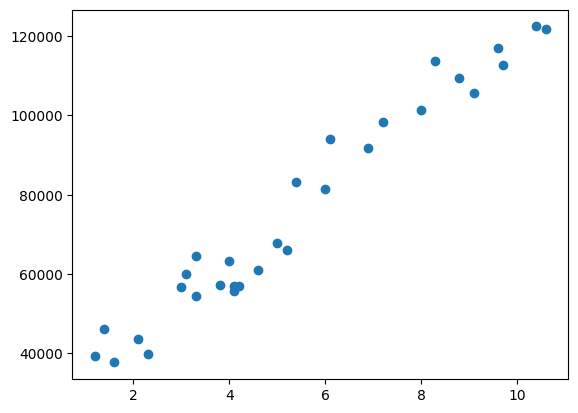

In [5]:
with open("./Salary_dataset.csv", mode="r") as csvFile:
  reader = csv.reader(csvFile)
  data = []
  skipHeader = True
  for row in reader:
    if skipHeader:
      skipHeader = False
      continue
    data.append((float(row[1]),float(row[2])))

plt.scatter([d[0] for d in data],[d[1] for d in data])

### Bad Trend Line

Define a function with a bad trendline 

In [20]:
def BadLine(x):
  m = 8000
  c = 38000
  return m * x + c

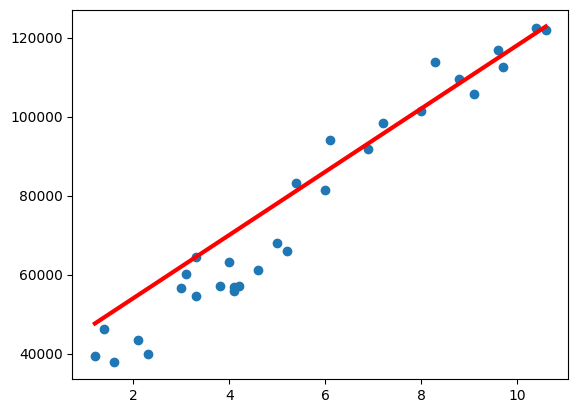

In [21]:
plt.plot([d[0] for d in data],[BadLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

The error between the *actual* data and the trend line can be calculated by first finding the difference between the predicted and the actual.

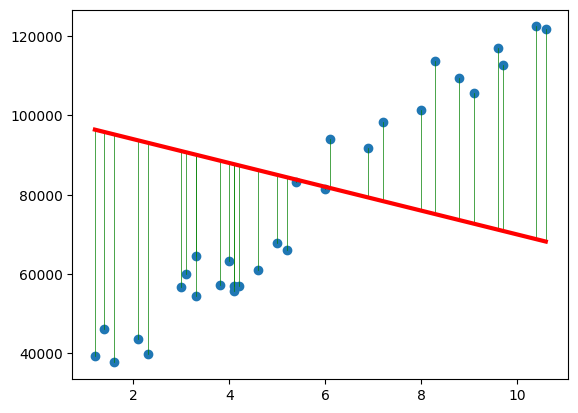

In [8]:
Errors = []
for datum in data:
  Errors.append(
      ((datum[0],datum[0]),
      (BadLine(datum[0]),datum[1]))
  )
for error in Errors:
  plt.plot(error[0],error[1],c='green',linewidth='0.5')


plt.plot([d[0] for d in data],[BadLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])


In [8]:
def MeanSquareError(data, line):
  TotalSquareError = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    TotalSquareError += (y - line(x))**2
  return TotalSquareError / len(data)

In [9]:
MeanSquareError(data,BadLine)

1298137757.7333333

Define a function for a better trend line

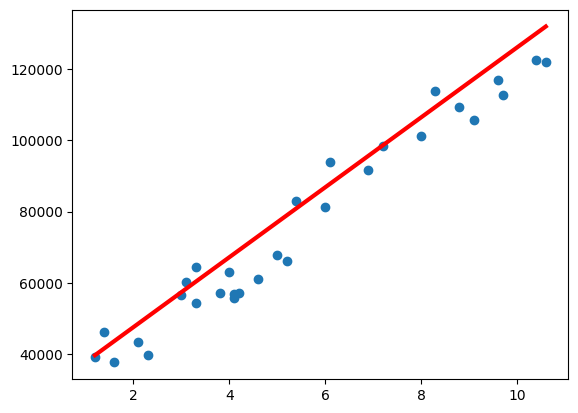

In [22]:
def BetterLine(x):
  m = 9800
  c = 28000
  return m * x + c

plt.plot([d[0] for d in data],[BetterLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

In [11]:
MeanSquareError(data,BetterLine)

82985357.73333332

## Finding better lines

First define a function with two parameters m,c for a general line, and a new function for MSE

In [9]:
def GenLine(x, m, c):
  return m * x + c

def MeanSquareError(data, m, c, line):
  TotalSquareError = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    TotalSquareError += (y - line(x, m, c))**2
  return TotalSquareError / len(data)


### Generate a heat map giving MSE for a set of lines

<Axes: xlabel='c - Intersect', ylabel='m - Gradient'>

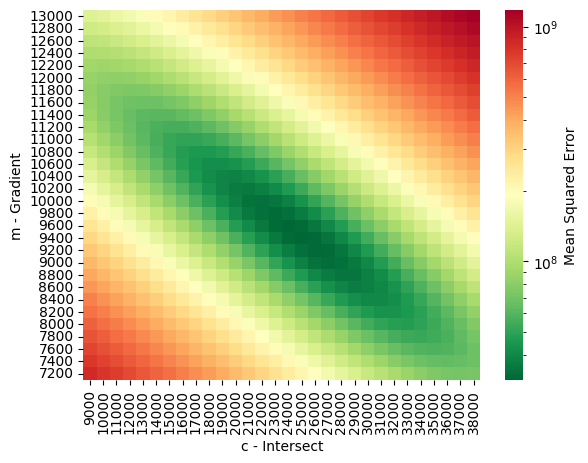

In [10]:

results = np.zeros((30,30))
mIntervals = np.arange(13000,7000,-200)
cIntervals = np.arange(9000,39000,1000)

for i,m in enumerate(mIntervals):
  for j,c in enumerate(cIntervals):
    results[i,j] = MeanSquareError(data, m, c, GenLine)
ax = sns.heatmap(results, xticklabels=cIntervals, yticklabels=mIntervals,norm=LogNorm(),cmap="RdYlGn_r",cbar_kws={'label': 'Mean Squared Error'})
ax.set(xlabel="c - Intersect", ylabel="m - Gradient")
ax

### Finding a better line

Now a function to update the M-parameter. Given m and c, for each point find the y-error between the actual and predicted value.
The total total = sum(x * error) and the change in m is total/len.

In [11]:
def UpdateM(data, m, c):
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    y_error = y - (m*x + c)
    Total += x * y_error
  return -2 * Total / len(data)


To update C, this is just the average of the y-errors. 

In [12]:

def UpdateC(data, m, c):
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    Total += (y - (m*x + c))
  return -2 * Total / len(data)

Now iterate. Start with the bad example, loop a thousand times, at each step update the m and c values.

In [33]:
learningRate = 0.025
#learningRate = 0.1
m = 10000
c = 10000

loss = [MeanSquareError(data,m,c,GenLine)]
mc = [{"m":m,"c":c}]

for iter in range(1000):
  _m = learningRate * UpdateM(data, m, c)
  c -= learningRate * UpdateC(data, m, c)
  m -= _m
  mean_sq_err = MeanSquareError(data,m,c,GenLine)
  loss.append( mean_sq_err)
  mc.append({"m":m,"c":c})
  if iter % 100 ==0:
    print(f"itt: {iter:4d} m: {m:5.0f}, c: {c:5.1f}, mse {mean_sq_err:9.0f}")

print(f"itt: {iter:4d} m: {m:5.0f}, c: {c:5.1f}, mse {mean_sq_err:9.0f}")
#print(f"m: {m:5.0f}, c: {c:5.1f}, mse {mean_sq_err:9.0f}")
MeanSquareError(data, m, c, GenLine)

itt:    0 m: 12999, c: 10593.5, mse 153894261
itt:  100 m: 10206, c: 19699.0, mse  36837027
itt:  200 m:  9719, c: 23015.1, mse  31976382
itt:  300 m:  9546, c: 24195.6, mse  31360356
itt:  400 m:  9484, c: 24615.9, mse  31282283
itt:  500 m:  9462, c: 24765.5, mse  31272388
itt:  600 m:  9454, c: 24818.8, mse  31271134
itt:  700 m:  9452, c: 24837.7, mse  31270975
itt:  800 m:  9451, c: 24844.5, mse  31270955
itt:  900 m:  9450, c: 24846.9, mse  31270952
itt:  999 m:  9450, c: 24847.7, mse  31270952


31270951.770217184

Define the best line using the final result of iteration

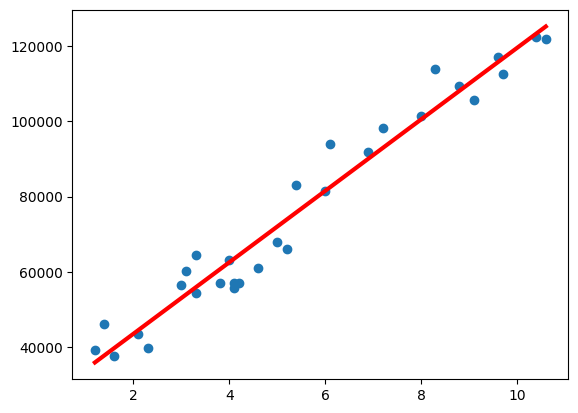

In [14]:
def BestLine(x):
  return m * x + c

plt.plot([d[0] for d in data],[BestLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

Plot the mean square errors for each iteration.

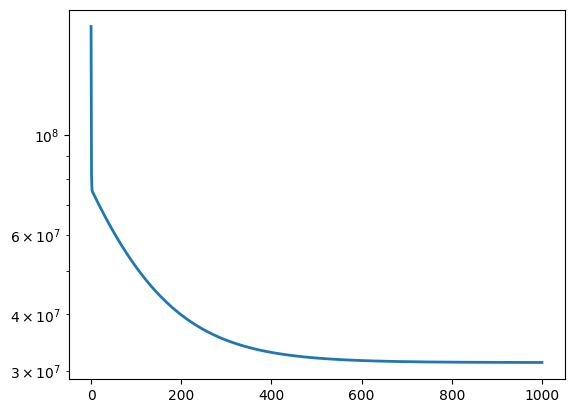

In [15]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

line, = ax.plot(loss, lw=2)

ax.set_yscale('log')

In [47]:
step_data = [[d['m'],d['c']] for d in mc]
m_vals = [d['m'] for d in mc]
c_vals = [d['c'] for d in mc]
step_data[0:5]

[[10000, 10000],
 [12998.887333333334, 10593.533333333333],
 [10275.788381022223, 10345.691161777777],
 [12669.66828024136, 10847.29321522554],
 [10488.410746555388, 10675.871673278934]]

<Axes: xlabel='c - Intersect', ylabel='m - Gradient'>

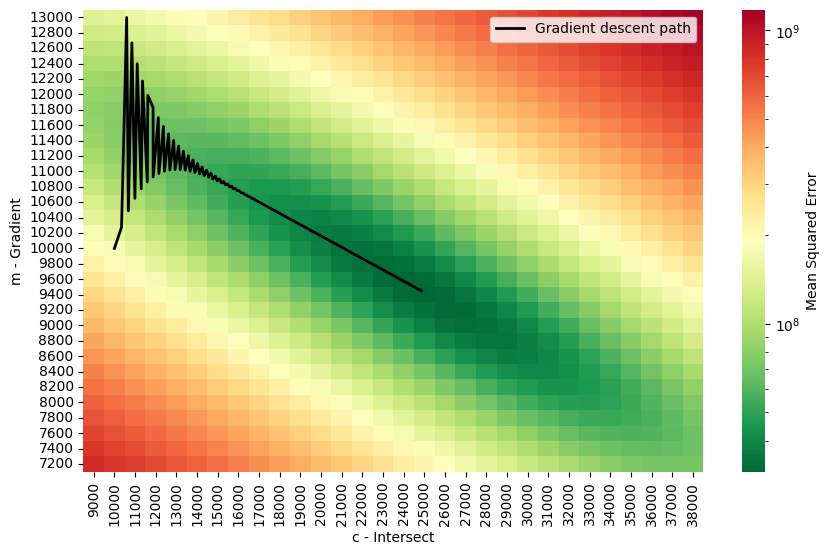

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
  results,
  xticklabels=cIntervals,
  yticklabels=mIntervals,
  norm=LogNorm(),
  cmap="RdYlGn_r",
  cbar_kws={'label': 'Mean Squared Error'},
  ax=ax
)
ax.set(xlabel="c - Intersect", ylabel="m - Gradient")

c_step = cIntervals[1] - cIntervals[0]
m_step = mIntervals[0] - mIntervals[1]

x_path = [(cv - cIntervals[0]) / c_step + 0.5 for cv in c_vals]
y_path = [(mIntervals[0] - mv) / m_step + 0.5 for mv in m_vals]

sns.lineplot(
  x=x_path,
  y=y_path,
  ax=ax,
  color="black",
  linewidth=2,
  label="Gradient descent path"
 )

ax.legend(loc="upper right")
ax